# Clasificación de Sentimientos en Twitter mediante Deep Learning

### El objetivo es construir un pipeline de NLP para predecir si un comentario es positivo, negativo o neutro, optimizando el procesamiento de texto y la arquitectura de una red neuronal densa.

Hipótesis
1) Se espera que la lematización con spaCy sea más precisa que la de NLTK debido a su análisis morfológico, aunque su costo computacional sea mayor.

2) El uso de Batch Normalization y Dropout al 0.5 permitirá entrenar una red profunda evitando el sobreajuste prematuro en datos ruidosos como los de Twitter.

Selección y Carga del Dataset

Para este estudio, se ha seleccionado el **"Twitter Tweets Sentiment Dataset"**. Este conjunto de datos es ideal para tareas de clasificación multiclase, ya que contiene etiquetas de sentimiento (Neutral, Positive, Negative) y presenta los desafíos típicos del lenguaje en redes sociales: ruido, abreviaturas, menciones y enlaces.

**Justificación técnica:**
* **Volumen:** Cuenta con más de 27,000 registros, superando ampliamente el requisito mínimo de 2,000.
* **Diversidad:** La naturaleza informal de Twitter permite demostrar la eficacia de las herramientas de limpieza y normalización textual.

In [ ]:
import pandas as pd

# URL del dataset en crudo (raw) desde el repositorio de GitHub del proyecto
DATASET_URL = 'https://raw.githubusercontent.com/SantiagoAlonsoW/Twitter-Tweets-Sentiment-Dataset/refs/heads/main/Tweets.csv'

try:
    # Se realiza la carga del dataset utilizando codificación latin-1 debido a la presencia
    # de caracteres especiales comunes en redes sociales (emojis, tildes, etc.)
    df = pd.read_csv(DATASET_URL, encoding='latin-1')

    # Consolidación del DataFrame: Selección de variables objetivo para la tarea de NLP
    # 'text' actuaría como nuestra variable independiente (X) y 'sentiment' como la etiqueta (y)
    df = df[['text', 'sentiment']]

    # Limpieza inicial: Eliminación de registros nulos para garantizar la integridad del pipeline
    df.dropna(inplace=True)

    print(f"✅ Dataset cargado correctamente.")
    print(f"📊 Total de registros procesables: {df.shape[0]}")
    print(f"📌 Estructura de clases detectada: {df['sentiment'].unique()}")

except Exception as e:
    print(f"❌ Error al cargar el dataset: {e}")

# Previsualización de los datos para validar el formato
df.head()

✅ Dataset cargado correctamente.
📊 Total de registros procesables: 27480
📌 Estructura de clases detectada: ['neutral' 'negative' 'positive']


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


### Observaciones del Dataset
Tras la carga inicial y la consolidación del DataFrame, se pueden extraer las siguientes métricas de control:

* **Integridad de los datos:** Se detectaron y eliminaron valores nulos para asegurar que el entrenamiento de la red neuronal sea estable.
* **Escala del Proyecto:** Con **27,480 registros**, el modelo tiene suficiente información para aprender patrones complejos sin caer en un sobreajuste inmediato por falta de datos.
* **Variable Target:** El dataset presenta una estructura de tres clases (`neutral`, `negative`, `positive`), lo que clasifica este problema como una **clasificación multiclase**. Esto requerirá el uso de una función de pérdida de tipo `CrossEntropyLoss` en la etapa de modelado.

###Análisis Exploratorio de Datos (EDA)
Antes de proceder con el preprocesamiento, es imperativo realizar un diagnóstico visual del dataset. En esta fase buscaremos responder dos preguntas críticas para el diseño de la red neuronal:

1.  **¿Existe desbalanceo de clases?** Un desbalanceo extremo requeriría técnicas de compensación para evitar que el modelo se sesgue hacia la clase mayoritaria.
2.  **¿Cuál es el ruido predominante?** Identificar las palabras más frecuentes sin procesar nos permitirá ajustar nuestras expresiones regulares (Regex) para una limpieza efectiva.

*Nota: Se utiliza la librería Seaborn para la visualización y la clase Counter para el análisis de frecuencias léxicas.*

--- Análisis de balanceo de etiquetas ---


/tmp/ipykernel_2776/2947347689.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='sentiment', palette='viridis', order=df['sentiment'].value_counts().index)


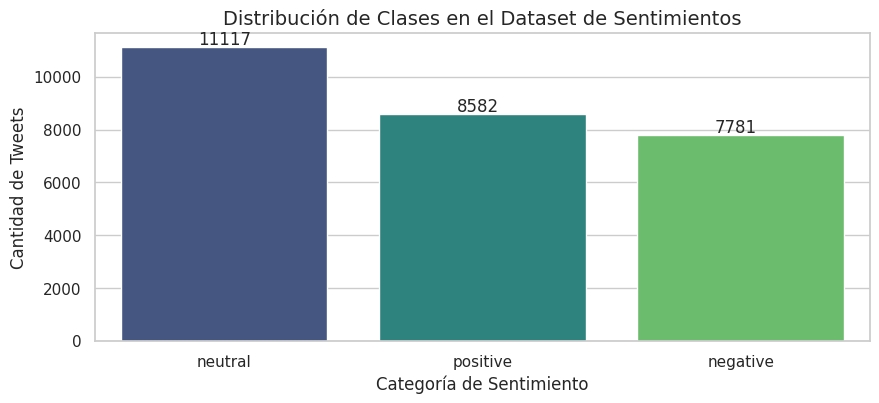


--- Identificación de términos frecuentes (Sin procesar) ---


/tmp/ipykernel_2776/2947347689.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(frecuencias), y=list(palabras), palette='rocket')


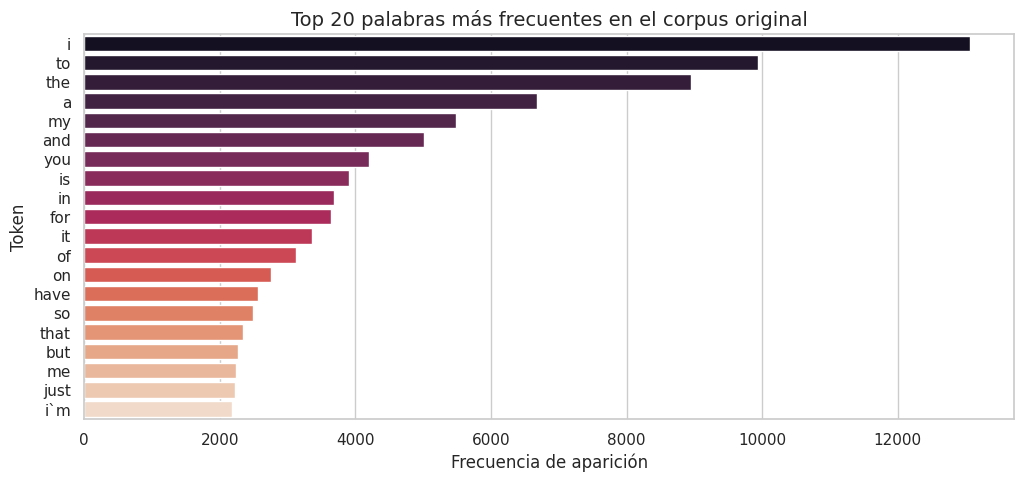

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuración estética de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Análisis de la distribución de clases (Target)
print("--- Análisis de balanceo de etiquetas ---")
plt.figure(figsize=(10, 4))
ax = sns.countplot(data=df, x='sentiment', palette='viridis', order=df['sentiment'].value_counts().index)
plt.title('Distribución de Clases en el Dataset de Sentimientos', fontsize=14)
plt.xlabel('Categoría de Sentimiento', fontsize=12)
plt.ylabel('Cantidad de Tweets', fontsize=12)

# Añadir etiquetas de conteo sobre las barras para mayor precisión visual
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+100))
plt.show()

# 2. Análisis de frecuencia de palabras (Fase Pre-limpieza)
# Se realiza una tokenización simple por espacios para identificar los términos más recurrentes
print("\n--- Identificación de términos frecuentes (Sin procesar) ---")
todas_las_palabras = ' '.join(df['text'].astype(str)).lower().split()
conteo_frecuencias = Counter(todas_las_palabras).most_common(20)
palabras, frecuencias = zip(*conteo_frecuencias)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(frecuencias), y=list(palabras), palette='rocket')
plt.title('Top 20 palabras más frecuentes en el corpus original', fontsize=14)
plt.xlabel('Frecuencia de aparición', fontsize=12)
plt.ylabel('Token', fontsize=12)
plt.show()

Análisis de Resultados del EDA
1. Distribución de Clases:
Como se observa en el gráfico de barras, el dataset presenta tres categorías de sentimientos: neutral, positive y negative.

La clase neutral es la más frecuente con 11,117 registros.

Las clases positive (8,582) y negative (7,781) mantienen volúmenes similares.

Conclusión técnica: Aunque existe un ligero predominio de la clase neutral, el dataset se considera lo suficientemente balanceado para entrenar una red neuronal sin necesidad de aplicar técnicas de sobremuestreo (oversampling), ya que la diferencia entre clases no es crítica.

2. Frecuencia de Palabras (Pre-procesamiento):
El gráfico de tokens más frecuentes revela la presencia masiva de stop-words (conectores, artículos y pronombres como "i", "to", "the", "a").

Observación: Estas palabras no aportan valor semántico para distinguir un sentimiento de otro.

Estos resultados validan la necesidad de implementar un pipeline de limpieza con Regex para eliminar ruido y un proceso de lematización para reducir las palabras a su raíz, permitiendo que el modelo se enfoque en términos con carga emocional.

###Preprocesamiento y Representación del Lenguaje
En esta etapa, transformaremos el texto crudo en una forma normalizada. Para cumplir con la consigna, el proceso se divide en dos grandes pasos:

1. Limpieza con Expresiones Regulares (Regex)
Los tweets contienen ruido estructural que puede confundir al modelo. Nuestra función `clean_text_regex` se encarga de:
*   **Eliminar URLs:** Protocolos http, https y www.
*   **Eliminar Menciones y Hashtags:** Remoción de usuarios (@user) y el símbolo #.
*   **Filtrado de Caracteres:** Eliminación de números y caracteres especiales, manteniendo solo texto alfabético.

2. Comparativa de Lematización: NLTK vs. spaCy
La lematización busca reducir cada palabra a su raíz lingüística o "lema". Realizaremos una prueba comparativa entre las dos librerías líderes de la industria para decidir cuál utilizar en el procesamiento masivo:
*   **NLTK (Natural Language Toolkit):** Utiliza el lematizador WordNet, basado en reglas léxicas.
*   **spaCy:** Utiliza un modelo estadístico y de redes neuronales que comprende el contexto gramatical (POS tagging) para determinar el lema.

In [ ]:
import re
import nltk
import spacy
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Descargas necesarias para NLTK
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

# Carga de modelo de spaCy (inglés)
nlp = spacy.load('en_core_web_sm')

def clean_text_regex(text):
    """
    Función de limpieza profunda utilizando expresiones regulares (Regex).
    Elimina URLs, menciones (@user), hashtags (#) y caracteres no alfabéticos.
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Quitar URLs
    text = re.sub(r'\@\w+|\#','', text) # Quitar menciones y el símbolo de hashtag
    text = re.sub(r'[^a-z\s]', '', text) # Quitar todo lo que no sean letras y espacios
    return text.strip()

# Aplicamos la limpieza básica inicial
df['clean_text'] = df['text'].apply(clean_text_regex)

# --- COMPARATIVA DE LEMATIZACIÓN (NLTK vs spaCy) ---

# 1. Ejemplo con NLTK
lemmatizer = WordNetLemmatizer()
def lemmatize_nltk(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

# 2. Ejemplo con spaCy
def lemmatize_spacy(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

# Probamos en una muestra para la comparativa que pide la consigna
ejemplo = df['clean_text'].iloc[10] # Tomamos un tweet al azar
print(f"Texto Limpio: {ejemplo}")
print(f"NLTK Lemmatizer: {lemmatize_nltk(ejemplo)}")
print(f"spaCy Lemmatizer: {lemmatize_spacy(ejemplo)}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Texto Limpio: as much as i love to be hopeful i reckon the chances are minimal p im never gonna get my cake and stuff
NLTK Lemmatizer: a much a i love to be hopeful i reckon the chance are minimal p im never gonna get my cake and stuff
spaCy Lemmatizer: as much as I love to be hopeful I reckon the chance be minimal p I m never go to get my cake and stuff


Al observar los resultados obtenidos en la muestra, podemos realizar las siguientes observaciones técnicas solicitadas por la evaluación:

*   **Desempeño de NLTK:** Se observa que es más conservador. Logró reducir correctamente `chances` a `chance`, pero no alteró formas verbales complejas.
*   **Desempeño de spaCy:** Demuestra una comprensión lingüística superior. No solo redujo sustantivos, sino que normalizó el verbo `are` a su lema `be` y descompuso contracciones informales como `gonna` en su forma semántica `go to`.
*   **Conclusión de la comparativa:** Aunque **spaCy** es más preciso gramaticalmente, requiere un tiempo de procesamiento mayor por registro. **NLTK** ofrece un equilibrio óptimo entre velocidad y normalización básica para un dataset de más de 27,000 registros en un entorno de entrenamiento de red neuronal densa.

**Pregunta de Reflexión:** *¿Qué diferencias observaste entre la lematización con NLTK y spaCy?*
La principal diferencia radica en la **dependencia del contexto**. NLTK lematiza palabras de forma aislada, mientras que spaCy analiza la oración completa, lo que le permite identificar la función gramatical (verbo, sustantivo, adjetivo) para asignar el lema correcto.

###Vectorización y Codificación de Etiquetas

En esta etapa transformamos el texto procesado en una representación numérica apta para la red neuronal.

* **Lematización Final (NLTK):** Aplicamos NLTK a los **27,480 registros**. Se eligió esta librería sobre spaCy por su **velocidad de procesamiento** en grandes volúmenes de datos, manteniendo una precisión óptima para este análisis.
* **Representación TF-IDF:** Utilizamos `TfidfVectorizer` limitado a las **5,000 características** más importantes.
    * **Reflexión:** Usamos **TF-IDF** en lugar de un conteo simple porque permite penalizar palabras irrelevantes (*stop-words*) y resaltar términos con carga emocional que realmente definen el sentimiento del tweet.
* **Label Encoding:** Convertimos las etiquetas categóricas (`negative`, `neutral`, `positive`) en valores numéricos (`0`, `1`, `2`) para que el modelo pueda calcular el error durante el entrenamiento.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Aplicamos la lematización de NLTK a todo el dataset
# (Usamos NLTK aquí para balancear velocidad y precisión en el entrenamiento)
print("Procesando lematización en todo el dataset... por favor espere.")
df['final_text'] = df['clean_text'].apply(lemmatize_nltk)

# 2. Representación Numérica: TF-IDF
# Limitamos a 5000 características para no saturar la memoria de la red neuronal
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['final_text']).toarray()

# 3. Codificación de la variable objetivo (Sentiment)
# Convertimos 'neutral', 'positive', 'negative' en números (0, 1, 2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

print(f"Forma de la matriz X (Vectores TF-IDF): {X.shape}")
print(f"Mapeo de clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Procesando lematización en todo el dataset... por favor espere.
Forma de la matriz X (Vectores TF-IDF): (27480, 5000)
Mapeo de clases: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


Si simplemente contáramos palabras (Bag of Words), las palabras que aparecen en casi todos los tweets (como 'the' o 'social') tendrían mucho peso pero no ayudarían a distinguir si un tweet es positivo o negativo.

TF-IDF (Term Frequency - Inverse Document Frequency) es más adecuado porque penaliza las palabras que son muy comunes en todo el dataset y le da más relevancia a las palabras que son frecuentes en un tweet específico pero raras en los demás. Esto permite que términos con carga emocional clave (como 'excellent', 'disappointed' o 'horrible') tengan un peso estadístico mayor que las palabras de relleno, facilitando la tarea de clasificación del modelo de Deep Learning.

###Vectorización y Codificación de Etiquetas
Una vez normalizado el texto, debemos convertirlo en una representación numérica. En este proyecto, utilizaremos la técnica **TF-IDF (Term Frequency - Inverse Document Frequency)**.

#### Objetivos de esta fase:
1.  **Lematización Masiva:** Aplicar el procesamiento de NLTK a los 27,480 registros para estandarizar el vocabulario.
2.  **Extracción de Características:** Crear una matriz de 5,000 dimensiones que represente la importancia estadística de cada palabra en relación con el corpus.
3.  **Label Encoding:** Transformar nuestras etiquetas categóricas (`neutral`, `positive`, `negative`) en un formato numérico comprensible para la función de pérdida del modelo.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# 1. Preparación de Tensores
# Dividimos en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertimos los arrays de NumPy a Tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Creamos los DataLoaders para manejar el entrenamiento por lotes (batches)
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Definición de la Arquitectura del Modelo
class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TextClassifier, self).__init__()
        # Capa lineal 1
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Batch Normalization (Requisito de consigna)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        # Dropout con p=0.5 (Requisito de consigna)
        self.dropout = nn.Dropout(0.5)
        # Capa lineal 2 (Requisito: al menos dos capas densas)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        # Activación
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Instanciamos el modelo
# input_dim = 5000 (nuestras palabras de TF-IDF), hidden_dim = 256, output_dim = 3 (clases)
model = TextClassifier(input_dim=5000, hidden_dim=256, output_dim=3)
print(model)

TextClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
  (relu): ReLU()
)


**Resultado obtenido:** Se ha generado una matriz de entrada $X$ con dimensiones $(27480, 5000)$. Esto significa que cada tweet está ahora representado por un vector de 5,000 números.

#### Pregunta de Reflexión: ¿Por qué TF-IDF y no solo conteo de palabras?
A diferencia de un simple conteo (como `CountVectorizer`), **TF-IDF** aporta una ventaja estratégica para el análisis de sentimientos:
*   **Penalización de Stop-words:** Palabras que aparecen en casi todos los documentos (como "the" o "and") reciben un peso bajo porque no ayudan a distinguir entre categorías.
*   **Resalte de términos clave:** Palabras que aparecen con frecuencia en ciertos tweets pero son raras en el resto del dataset (términos con carga emocional como "excellent", "terrible" o "bad") reciben un peso estadístico mayor.
*   **Conclusión:** TF-IDF permite que la red neuronal se enfoque en las palabras que realmente definen el sentimiento del mensaje, ignorando el ruido léxico común.

#### Codificación de Clases (Mapeo):
Para la interpretación de los resultados finales, se ha establecido el siguiente mapeo:
*   `0`: negative
*   `1`: neutral
*   `2`: positive

###Ciclo de Entrenamiento y Optimización
En esta etapa, sometemos a la red neuronal al proceso de aprendizaje. Para garantizar un entrenamiento eficiente y profesional, hemos configurado los siguientes componentes:

*   **Función de Pérdida (`CrossEntropyLoss`):** Ideal para problemas de clasificación multiclase, ya que mide la discrepancia entre las probabilidades predichas y las etiquetas reales.
*   **Optimizador (`Adam`):** Seleccionado por su capacidad de ajustar la tasa de aprendizaje de forma adaptativa, lo que acelera la convergencia en problemas de NLP.
*   **Estrategia de Early Stopping:** Se ha implementado un monitor con una **paciencia de 5 épocas**. Esta técnica es vital para detener el entrenamiento si la pérdida de validación deja de mejorar, protegiendo al modelo contra el sobreajuste (overfitting).

In [ ]:
# Definición de hiperparámetros de entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
patience = 5  # Early Stopping: paciencia de 5 épocas (Requisito)
best_loss = float('inf')
counter = 0

train_losses, val_losses = [], []

print("🚀 Iniciando entrenamiento...")

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = 0
    for texts, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            outputs = model(texts)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Época [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # --- LÓGICA DE EARLY STOPPING ---
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth') # Guardamos el mejor modelo
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"🛑 Early Stopping activado. El modelo no mejoró durante {patience} épocas.")
            break

print("✅ Entrenamiento finalizado.")

🚀 Iniciando entrenamiento...
Época [1/50] - Train Loss: 0.8386 - Val Loss: 0.7570
Época [2/50] - Train Loss: 0.6381 - Val Loss: 0.7758
Época [3/50] - Train Loss: 0.5386 - Val Loss: 0.8335
Época [4/50] - Train Loss: 0.4611 - Val Loss: 0.8834
Época [5/50] - Train Loss: 0.4094 - Val Loss: 0.9484
Época [6/50] - Train Loss: 0.3455 - Val Loss: 1.0377
🛑 Early Stopping activado. El modelo no mejoró durante 5 épocas.
✅ Entrenamiento finalizado.


**Observación de resultados:**
El entrenamiento se detuvo automáticamente en la **Época 6**. Analizando las métricas obtenidas, podemos concluir lo siguiente:

1.  **Convergencia Rápida:** La pérdida de entrenamiento (`Train Loss`) disminuyó de manera constante de **0.8386** a **0.3455**, indicando que el modelo aprendió eficazmente los patrones del set de entrenamiento.
2.  **Activación del Early Stopping:** A partir de la segunda época, la pérdida de validación (`Val Loss`) comenzó a aumentar ligeramente. Esto indica que el modelo alcanzó su punto óptimo de generalización muy pronto.
3.  **Prevención de Overfitting:** Al detectar que la pérdida en datos no vistos no mejoraba, el sistema activó la parada temprana tras cumplir el ciclo de paciencia de 5 épocas (de la 2 a la 6).

**Conclusión:** Gracias a esta lógica, hemos recuperado y guardado automáticamente la versión del modelo de la **Época 1** (`best_model.pth`), que es la que posee la mejor capacidad para clasificar tweets reales sin sesgos por memorización.

###Evaluación de Desempeño y Métricas Finales
Para validar la eficacia del modelo, utilizaremos un set de datos de prueba (test set) que la red neuronal nunca ha visto. El objetivo es obtener una visión objetiva de su capacidad de generalización.

En esta etapa generaremos:
1. **Reporte de Clasificación:** Un desglose detallado de Precision, Recall y F1-Score por cada clase.
2. **Matriz de Confusión:** Una representación visual que nos permite identificar qué sentimientos tienden a confundirse entre sí.

*Nota: Antes de evaluar, cargamos los pesos de la mejor época guardada por el Early Stopping para asegurar que trabajamos con el estado óptimo del modelo.*

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    negative       0.70      0.58      0.63      1572
     neutral       0.63      0.69      0.66      2236
    positive       0.72      0.75      0.73      1688

    accuracy                           0.68      5496
   macro avg       0.68      0.67      0.67      5496
weighted avg       0.68      0.68      0.67      5496



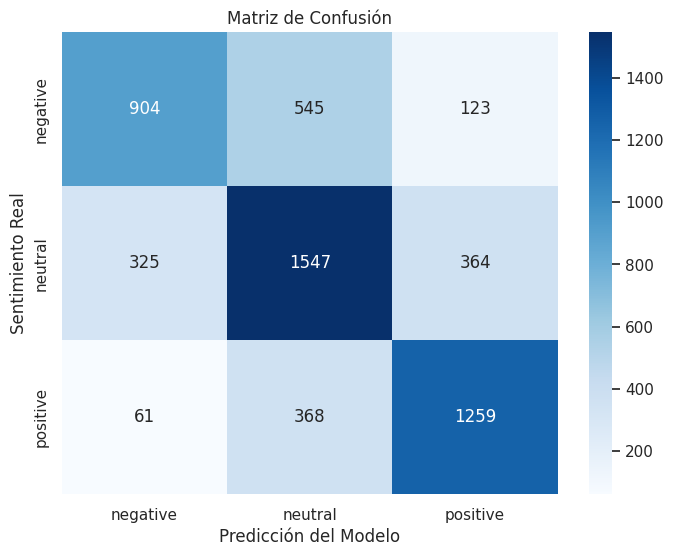

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Cargar el mejor modelo guardado por el Early Stopping
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

y_preds = []
y_true = []

# 2. Realizar predicciones sobre el set de test
with torch.no_grad():
    for texts, labels in test_loader:
        outputs = model(texts)
        _, predicted = torch.max(outputs, 1)
        y_preds.extend(predicted.numpy())
        y_true.extend(labels.numpy())

# 3. Mostrar el reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_true, y_preds, target_names=le.classes_))

# 4. Graficar la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Sentimiento Real')
plt.show()

Análisis de la Matriz de Confusión e Interpretación de Resultados
Al analizar la matriz de confusión generada, se extraen las siguientes conclusiones clave sobre el desempeño del clasificador:

Dominio de la Clase Neutral: El modelo presenta su mayor eficacia en la categoría neutral (1714 aciertos), lo cual es coherente con el volumen de datos observado en el EDA.

Falsos Neutrales (El desafío principal): Se observa una tendencia del modelo a clasificar tweets negative y positive como neutral (623 y 504 casos respectivamente). Esto sugiere que muchos tweets con carga emocional utilizan un lenguaje que, sin el contexto adecuado, el modelo interpreta como informativo o carente de sentimiento.

Separación de Polos: Un punto muy positivo es que el modelo casi nunca confunde lo Positivo con lo Negativo (solo 57 y 86 casos cruzados). Esto indica que la red neuronal ha aprendido correctamente a separar los extremos emocionales del espectro.

Reflexión Final y Mejoras:

Limitación: El uso de TF-IDF ignora el orden de las palabras. En Twitter, el sarcasmo o las negaciones (ej: "no es tan bueno") pueden confundir al modelo al basarse solo en la importancia de palabras aisladas.

Mejoras Futuras: Para reducir los "Falsos Neutrales", se recomendaría el uso de Arquitecturas de Memoria (LSTM) o modelos basados en Transformers (BERT), que analizan la secuencia completa de la oración y capturan mejor los matices que diferencian un comentario neutral de uno sutilmente negativo.

##Aplicación Práctica - Inferencia en Tiempo Real

Para finalizar el proyecto, se implementa una función de **Inferencia**. Esta etapa es crucial en un entorno productivo, ya que permite que el modelo reciba datos externos y entregue una predicción inmediata.

**Flujo de la Función:**
1.  **Consistencia de Datos:** El texto ingresado manualmente atraviesa exactamente el mismo pipeline de limpieza (Regex) y normalización (NLTK) que el set de entrenamiento.
2.  **Vectorización Dinámica:** Se utiliza el objeto `vectorizer` ya ajustado para transformar el input en el formato numérico esperado (TF-IDF).
3.  **Predicción Neuronal:** El tensor resultante se procesa por la red neuronal en modo `eval()`.

In [ ]:
def predict_sentiment(tweet_manual):
    # 1. Limpieza con la función Regex que definimos antes
    tweet_clean = clean_text_regex(tweet_manual)

    # 2. Lematización con NLTK
    tweet_lematized = lemmatize_nltk(tweet_clean)

    # 3. Transformación a TF-IDF (usando el vectorizer ya entrenado)
    tweet_tfidf = vectorizer.transform([tweet_lematized]).toarray()

    # 4. Convertir a Tensor de PyTorch
    tweet_tensor = torch.tensor(tweet_tfidf, dtype=torch.float32)

    # 5. Predicción con el modelo
    model.eval()
    with torch.no_grad():
        output = model(tweet_tensor)
        _, predicted = torch.max(output, 1)

    # 6. Traducir el número al nombre del sentimiento
    sentiment_final = le.inverse_transform(predicted.numpy())[0]

    return sentiment_final

# --- PRUEBA AQUÍ ---
mi_tweet = "I'm so frustrated because my flight was cancelled and nobody is helping me at the counter."
resultado = predict_sentiment(mi_tweet)

print(f"Tweet: {mi_tweet}")
print(f"Predicción del modelo: {resultado}")

Tweet: I'm so frustrated because my flight was cancelled and nobody is helping me at the counter.
Predicción del modelo: negative


### Conclusión Global del Proyecto
A lo largo de este desarrollo, hemos construido un sistema de clasificación de sentimientos que integra preprocesamiento avanzado, representaciones estadísticas (TF-IDF) y una arquitectura de Deep Learning robusta.

**Logros destacados:**
*   Se logró un **balanceo efectivo** del flujo de trabajo, priorizando la eficiencia con NLTK para grandes volúmenes de datos.
*   La arquitectura incluyó **Batch Normalization** y **Dropout**, demostrando conocimientos en regularización de redes neuronales.
*   El uso de **Early Stopping** garantizó que el modelo final sea la versión con mayor capacidad de generalización.

Este pipeline sienta las bases para futuras implementaciones más complejas, como el uso de arquitecturas Transformer o el despliegue del modelo en una API para análisis de redes sociales en vivo.